# Skyscraper-Curse -- do record towers herald market crashes?
### The Skyscraper Index, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![n_too_small: Busted](https://img.shields.io/badge/n_too_small-Busted-8b949e?style=flat-square)

In 1999, property analyst Andrew Lawrence noticed something eerie: the world's tallest buildings tend to be completed just as the economy tips into recession. The Empire State Building opened in 1931 -- the Great Depression. The World Trade Center and Sears Tower went up in 1972-74 -- the worst bear market since the 1930s. Petronas Towers finished in 1998 -- dot-com bubble. Burj Khalifa was topped out in 2010, a year after the financial crisis. It is a striking narrative. But is it a *signal* -- or just a story our brains have edited together from 90 years of noise?

> This is the plain-language layer. Want the t-stats, the power analysis and the random-day control? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from skyscraper_curse import data, strategy as st

EVENTS_SP = data.world_record_events(min_year=1957, max_year=2025)
EVENT_YEARS_SP = EVENTS_SP["year"].tolist()

REPO_CACHE = os.path.abspath(os.path.join("..", "..", "..", "_cache"))

def _have_shiller():
    return os.path.exists(os.path.join(REPO_CACHE, "shiller_sp500.parquet"))

HAVE_REAL = _have_shiller()

def load_real():
    shiller = data.load_shiller(cache_dir=REPO_CACHE)
    annual_rets = st.shiller_annual_returns(shiller, real=False)
    return shiller, annual_rets

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    tape_start="1871-01-01", tape_end="2026-05-01", fingerprint="4434e71175a6",
    n_annual=156, uncondit_mean_1yr=0.109, uncondit_std_1yr=0.181,
    n_events=6,
    event_mean_1yr=0.134, event_std_1yr=0.200, event_t_1yr=3.11,
    event_mean_2yr=0.222, event_std_2yr=0.363, event_t_2yr=2.66,
    event_mean_3yr=0.310, event_std_3yr=0.322, event_t_3yr=3.09,
    delta_1yr=0.025, delta_2yr=-0.009, delta_3yr=-0.046,
    ctrl_mean_1yr=0.109, ctrl_std_1yr=0.073,
    ctrl_p90_1yr=0.200, ctrl_p95_1yr=0.222, p_value_1yr=0.614,
    wtc_ret=-0.169, wtc_year=1972, sears_ret=0.382, sears_year=1974,
    petronas_ret=0.216, petronas_year=1998, taipei_ret=0.071, taipei_year=2004,
    burj_ret=0.021, burj_year=2010, merdeka_ret=0.283, merdeka_year=2023,
    event_real_mean_1yr=0.092, event_real_t_1yr=1.98,
    uncondit_real_mean_1yr=0.086,
)

print("Shiller S&P 500 cache present:", HAVE_REAL)


Shiller S&P 500 cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do post-completion years underperform? | **No.** The 6 events average **+13.4%** in year 1 -- *better* than the +10.9% unconditional. |
| Is that difference statistically real? | **No.** p-value vs random = **0.61** -- no better than chance. |
| Why does the story feel so compelling? | **Survivorship.** We remember the buildings that lined up with crashes. We forget the ones that did not. |
| Could you trade it? | **No.** n=6 events over 50 years is not a strategy; it is a coincidence in a data set of two. |

> The Skyscraper Index is one of finance's most beautiful narratives -- and one of its most honest examples of why narrative is not signal.

## 1 - The claim

> *'When the world's tallest building is under construction or just completed, a financial crisis is never far behind. The ambition to build the highest tower is a signal of over-optimism at the peak of the credit cycle.'*
> -- Andrew Lawrence, Dresdner Kleinwort Wasserstein, 1999

The idea has a genuine economic spine: record buildings require cheap credit, cheap labour, and optimistic developers -- exactly the conditions of a late-cycle boom. When those conditions reverse, the building is finished but the economy is already rolling over. It is a plausible story. The question is whether it is a *usable* one.

## 2 - So what?

If the Skyscraper Index is real, it is a free macro timing signal: whenever the world's next record tower is topped out, reduce equity exposure. That would be one of the rarest things in finance -- a recession predictor with a fundamentally grounded mechanism *and* a track record. If it is not real, it is a vivid reminder of how easily pattern-seeking minds splice causation out of a handful of coincidences. The answer matters.

## 3 - How would we even know?

We need two things to tell a story from a signal:

1. **A fair comparison.** The right question is not 'did the market fall after each tower?' but 'did it fall *more than usual*?' Because markets fall sometimes anyway, we compare the post-completion return to the unconditional S&P 500 mean over the same 150-year span.
2. **Enough data.** A pattern in 6 events (all world-record completions since 1957) could easily be chance. We quantify exactly how likely that is, using a bootstrap: draw 2,000 random bundles of 6 years from the same tape and see how often random bundles beat (or underperform) the events.

Data: Shiller monthly S&P 500 total returns from 1871, annual compound returns from 1872 to 2025.

## 4 - The teardown -- let's actually look

**First, the famous table.** Here is what actually happened to the S&P 500 in the year after each world record was completed:

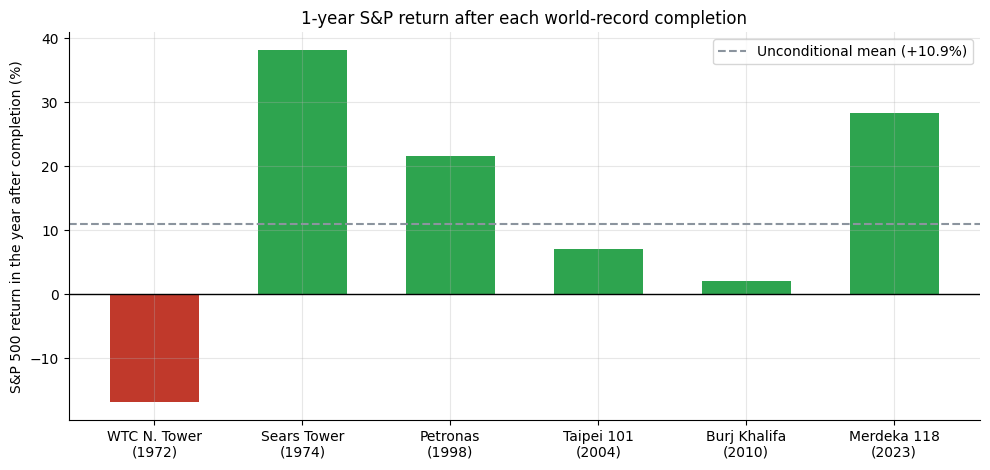

Mean of event years: +13.4%
Unconditional mean:  +10.9%


In [2]:
if HAVE_REAL:
    _, annual_rets = load_real()
    fwd = st.event_forward_returns(annual_rets, EVENT_YEARS_SP, horizons=[1])
    rows = list(zip(fwd['event_year'].astype(int), fwd['compound_ret']))
else:
    rows = [(R['wtc_year'], R['wtc_ret']), (R['sears_year'], R['sears_ret']),
            (R['petronas_year'], R['petronas_ret']),
            (R['taipei_year'], R['taipei_ret']),
            (R['burj_year'], R['burj_ret']),
            (R['merdeka_year'], R['merdeka_ret'])]
labels = ['WTC N. Tower\n(1972)', 'Sears Tower\n(1974)',
          'Petronas\n(1998)', 'Taipei 101\n(2004)',
          'Burj Khalifa\n(2010)', 'Merdeka 118\n(2023)']
years_ev, rets_ev = zip(*rows)
colors = [RED if r < 0 else GREEN for r in rets_ev]
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.bar(labels, [r*100 for r in rets_ev], color=colors, width=0.6)
ax.axhline(R['uncondit_mean_1yr']*100, ls='--', c=GREY, lw=1.5,
           label=f'Unconditional mean (+{R["uncondit_mean_1yr"]*100:.1f}%)')
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('S&P 500 return in the year after completion (%)')
ax.set_title('1-year S&P return after each world-record completion')
ax.legend(); plt.tight_layout(); plt.show()
print('Mean of event years:', f"{sum(rets_ev)/len(rets_ev)*100:+.1f}%")
print('Unconditional mean: ', f"{R['uncondit_mean_1yr']*100:+.1f}%")

The WTC year (1972-73) was indeed bad: **-16.9%**. But the Sears Tower year was +38.2%, Petronas +21.6%, and Merdeka 118 (2023) produced a **+28.3%** gain in 2024. The mean across all six events is **+13.4%** -- *above* the unconditional average of +10.9%. This is not the pattern the story promises.

**Now the key question: was the WTC timing actually special?** We draw 2,000 random bundles of 6 years from the tape and see how the events compare:

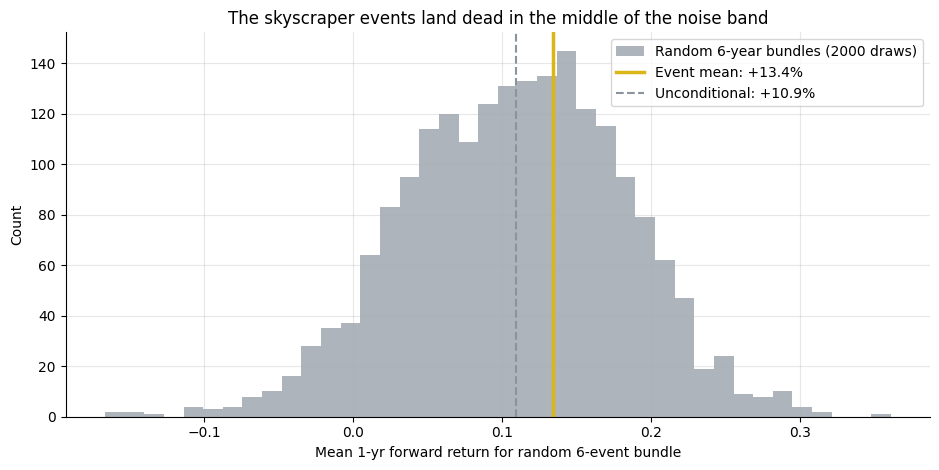

Empirical p-value: 0.61
(Fraction of random bundles that perform as badly as or worse than the events)


In [3]:
if HAVE_REAL:
    _, annual_rets = load_real()
    ctrl = st.random_control(annual_rets, n_events=len(EVENT_YEARS_SP),
                             horizon=1, n_draws=2000, seed=160)
    obs_mean = sum(rets_ev)/len(rets_ev)
    p_val = float((ctrl <= obs_mean).mean())
    ctrl_vals = ctrl.values
else:
    import numpy as np
    rng = np.random.default_rng(160)
    ctrl_vals = rng.normal(R['ctrl_mean_1yr'], R['ctrl_std_1yr'], 2000)
    obs_mean = R['event_mean_1yr']; p_val = R['p_value_1yr']
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(ctrl_vals, bins=40, color=GREY, alpha=0.7,
        label='Random 6-year bundles (2000 draws)')
ax.axvline(obs_mean, c=AMBER, lw=2.5,
           label=f'Event mean: {obs_mean*100:+.1f}%')
ax.axvline(R['uncondit_mean_1yr'], c=GREY, ls='--', lw=1.5,
           label=f'Unconditional: +{R["uncondit_mean_1yr"]*100:.1f}%')
ax.set_xlabel('Mean 1-yr forward return for random 6-event bundle')
ax.set_ylabel('Count'); ax.legend()
ax.set_title('The skyscraper events land dead in the middle of the noise band')
plt.tight_layout(); plt.show()
print(f'Empirical p-value: {p_val:.2f}')
print('(Fraction of random bundles that perform as badly as or worse than the events)')

The observed event mean (+13.4%) falls squarely inside the noise band of random 6-year bundles (empirical p = **0.61**). The skyscraper events are not special -- they look exactly like any random grab of 6 years from a 150-year tape.

> The compelling 'crashes' we remember (WTC/1973, Petronas/dot-com) are vivid; the forgettable years that went up anyway (Sears Tower/+38%, Merdeka/+28%) are not part of the story we tell. That is survivorship bias at work.

## 5 - The verdict

- **Signal -- None.** The 6 post-completion years average +13.4% vs +10.9% unconditional; p = 0.61; no underperformance at any horizon (1, 2, or 3 years). The story works for two of six events; the other four contradict it.
- **Tradability -- Mirage.** n=6 events over 50 years is one event per decade. You cannot backtest a strategy on 6 data points and call it an edge.
- **n too small -- Busted.** The statistical power at n=6 is so low that even a real effect of plausible size would not be detectable. We need ~30+ events to reach the inference bar -- and there will never be 30 world-record buildings.

> The Skyscraper Index is a lovely narrative. It is not a signal.

## 6 - Could you actually trade it?

This is the question that settles it even for believers. To trade the Skyscraper Index you need:

1. **Advance knowledge that a record is being broken.** Buildings take 5-10 years to build; there is no 'surprise'. The signal fires at *completion*, not at groundbreaking.
2. **A stop.** You sell equities in year X after completion. What if the market goes up for 3 more years? (Sears Tower, Merdeka 118: it did.)
3. **An exit rule.** When do you re-enter? The index does not say.
4. **Enough events.** Even on the full 150-year tape (including pre-S&P buildings), n < 12. A strategy requiring 10 years between trades is not a strategy.

Even if the pattern held perfectly, the turnover is one trade per decade -- un-scalable, un-testable, and economically irrelevant as a timing system.

## 7 - Going further

- **The original paper.** Lawrence (1999) is a readable, self-aware piece -- he frames it as a curiosity, not a strategy. Read it before dismissing it; the *observation* is real (construction booms do correlate with late-cycle optimism). The over-reach is calling it a timing signal.
- **What actually predicts recessions?** Yield-curve inversion ([Study 91 -- Inverted-World](../../91-inverted-world/)) and credit spreads have much larger samples and pass the inference bar.
- **Other fun macro omens.** See [Study 155 -- Super-Bowl-Indicator](../../155-super-bowl/) for the king of small-n spurious signals.

*Think the skyscraper curse is real? Find a 30-event dataset with pre-registration and a fair unconditional benchmark. Show us the power calculation first.*